In [5]:
import os

# Data was moved from Google Drive to local filesystem.
# Path is relative to the notebook's working directory (repo root).
BASE_DATA_DIR = os.path.join(".", "data")

In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from tqdm import tqdm

In [7]:
# Define Dataset Paths
respiratory_path = os.path.join(
    BASE_DATA_DIR,
    "datasets",
    "Respiratory_Sound_Database",
    "Respiratory_Sound_Database",
)

csv_path = os.path.join(
    respiratory_path,
    "patient_diagnosis.csv"
)

audio_path = os.path.join(
    respiratory_path,
    "audio_and_txt_files"
)

In [8]:
# Load Diagnosis CSV
diagnosis_df = pd.read_csv(
    csv_path,
    names=["patient_id", "disease"]
)

diagnosis_df.head()

,patient_id,disease
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [9]:
# Create Diagnosis Dictionary
diagnosis_dict = {}

for _, row in diagnosis_df.iterrows():
    diagnosis_dict[str(row["patient_id"])] = row["disease"]

print("Total Patients:", len(diagnosis_dict))

Total Patients: 126


In [10]:
# Load Audio Files and Labels
audio_files = []
labels = []

for file in os.listdir(audio_path):

    if file.endswith(".wav"):

        patient_id = file.split("_")[0]

        if patient_id in diagnosis_dict:

            audio_files.append(
                os.path.join(audio_path, file)
            )

            labels.append(
                diagnosis_dict[patient_id]
            )

print("Total Audio Files:", len(audio_files))
print("Sample Labels:", labels[:10])

Total Audio Files: 666
Sample Labels: ['COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD', 'COPD']


In [11]:
# Filter Important Disease Classes
selected_classes = [
    "COPD",
    "Pneumonia",
    "Healthy",
    "URTI",
    "Bronchiectasis"
]

filtered_audio_files = []
filtered_labels = []

for file, label in zip(audio_files, labels):

    if label in selected_classes:

        filtered_audio_files.append(file)
        filtered_labels.append(label)

print("Filtered Samples:", len(filtered_audio_files))

Filtered Samples: 659


In [12]:
# Full MFCC Extraction Function
def extract_full_mfcc(
    file_path,
    max_len=200,
    n_mfcc=40
):

    try:

        audio, sr = librosa.load(
            file_path,
            sr=22050
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=n_mfcc
        )

        if mfcc.shape[1] < max_len:

            pad_width = max_len - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                pad_width=((0, 0), (0, pad_width)),
                mode='constant'
            )

        else:

            mfcc = mfcc[:, :max_len]

        return mfcc

    except:

        return None

In [13]:
# Test on One Audio File
sample_mfcc = extract_full_mfcc(
    filtered_audio_files[0]
)

print(sample_mfcc.shape)

/Users/abhishekkumar/Documents/intern_aicahealth/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(40, 200)


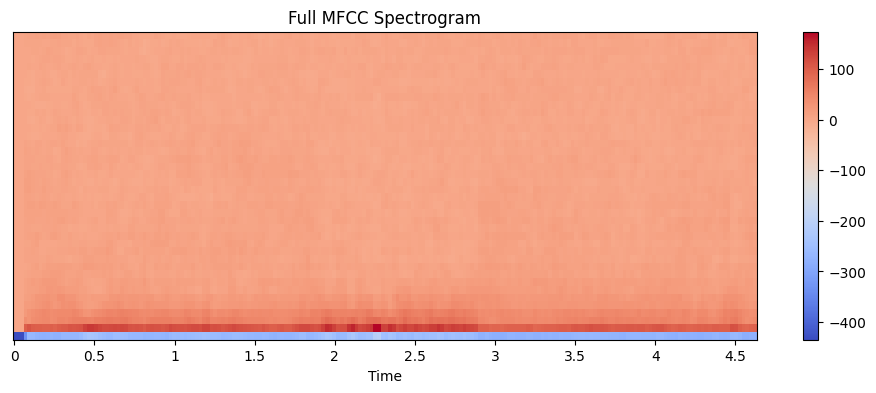

In [14]:
# Visualize MFCC Spectrogram
plt.figure(figsize=(12,4))

librosa.display.specshow(
    sample_mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("Full MFCC Spectrogram")
plt.show()

In [15]:
# Generate MFCC Dataset
X = []
y = []

for file, label in tqdm(
    zip(filtered_audio_files, filtered_labels),
    total=len(filtered_audio_files)
):

    mfcc = extract_full_mfcc(file)

    if mfcc is not None:

        X.append(mfcc)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

  0%|          | 0/659 [00:00<?, ?it/s]

100%|██████████| 659/659 [00:07<00:00, 83.31it/s]

(659, 40, 200)
(659,)


In [16]:
# Add CNN Channel Dimension
X = X[..., np.newaxis]

print(X.shape)

(659, 40, 200, 1)


In [17]:
np.save(
    os.path.join(BASE_DATA_DIR, "X_mfcc_spectrogram.npy"),
    X
)

np.save(
    os.path.join(BASE_DATA_DIR, "y_labels.npy"),
    y
)

print("MFCC Spectrogram Dataset Saved")

MFCC Spectrogram Dataset Saved


In [18]:
X[0]

array([[[-434.9676   ],
        [-434.9676   ],
        [-434.9676   ],
        ...,
        [-284.45248  ],
        [-279.82443  ],
        [-279.78867  ]],

       [[   0.       ],
        [   0.       ],
        [   0.       ],
        ...,
        [  89.26659  ],
        [  92.702194 ],
        [  95.40149  ]],

       [[   0.       ],
        [   0.       ],
        [   0.       ],
        ...,
        [  36.59458  ],
        [  40.147045 ],
        [  45.015873 ]],

       ...,

       [[   0.       ],
        [   0.       ],
        [   0.       ],
        ...,
        [   1.0098809],
        [   8.4023695],
        [   7.6878514]],

       [[   0.       ],
        [   0.       ],
        [   0.       ],
        ...,
        [   1.5044044],
        [   7.9917374],
        [   5.352246 ]],

       [[   0.       ],
        [   0.       ],
        [   0.       ],
        ...,
        [   6.9644375],
        [   4.1914754],
        [   3.2292128]]], shape=(40, 200, 1), dtype=float32

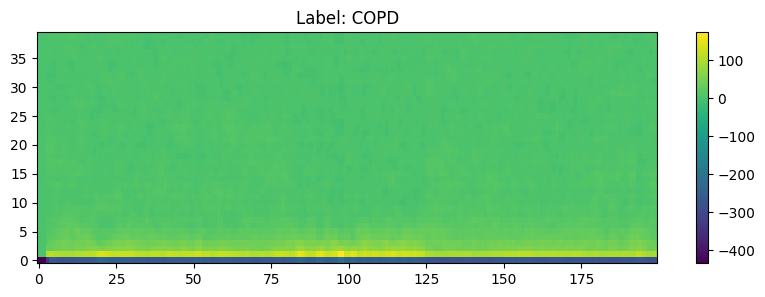

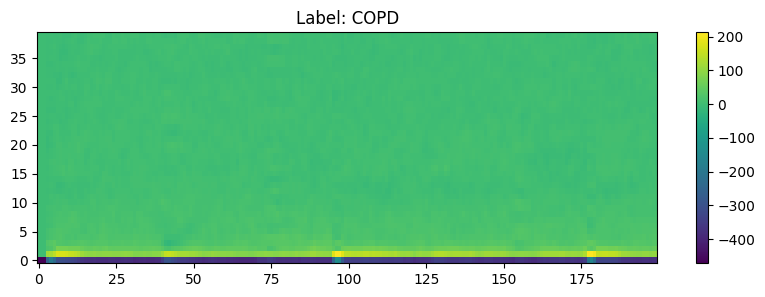

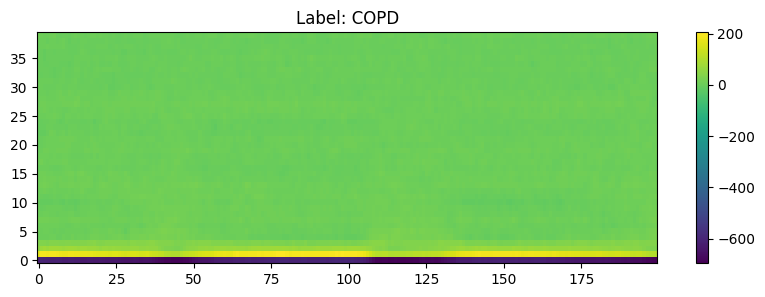

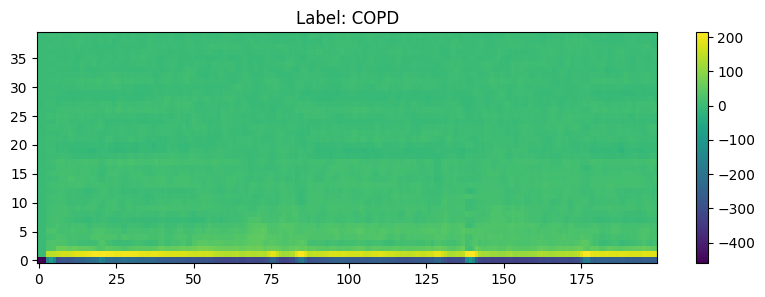

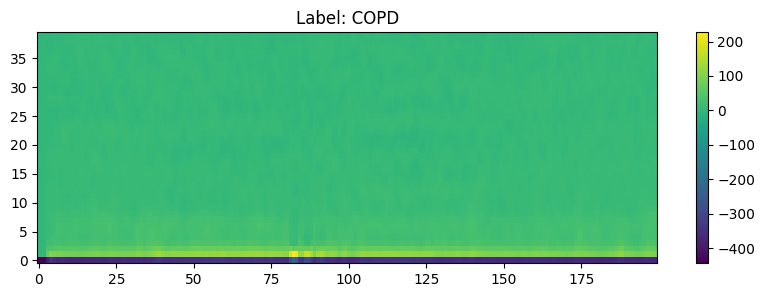

In [19]:
for i in range(5):
    plt.figure(figsize=(10,3))
    plt.imshow(X[i], aspect='auto', origin='lower')
    plt.title(f"Label: {y[i]}")
    plt.colorbar()
    plt.show()